# Red neuronal de ropa

In [125]:
import tensorflow as tf
import numpy as np
import datetime

from tensorflow.keras.datasets import fashion_mnist

tf.__version__

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

x_train.shape

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=128,activation='relu', input_shape=(784, )))
model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['sparse_categorical_accuracy'])

model.summary()

model.fit(x_train, y_train, epochs=5)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy: {}".format(test_accuracy))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_87 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4952 - sparse_categorical_accuracy: 0.8269
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3732 - sparse_categorical_accuracy: 0.8664
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3381 - sparse_categorical_accuracy: 0.8767
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3135 - sparse_categorical_accuracy: 0.8855
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2941 - sparse_categorical_accuracy: 0.8924
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3420 - sparse_categorical_accuracy: 0.8778
Test accuracy: 0.8777999877929688


**Codigo con capa dropout para evitar el sobreentrenamiento.**

In [126]:
import tensorflow as tf
import numpy as np
import datetime

from tensorflow.keras.datasets import fashion_mnist

tf.__version__

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

x_train.shape

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=128,activation='relu', input_shape=(784, )))
model.add(tf.keras.layers.Dropout(0.2)) # Esta capa de dropout elimina un 20% de neuronas y conexiones.
model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['sparse_categorical_accuracy'])

model.summary()

model.fit(x_train, y_train, epochs=5)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy: {}".format(test_accuracy))

model.save_weights("mimodelo.weights.h5") # guardar el modelo entrenado

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_89 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.5354 - sparse_categorical_accuracy: 0.8104
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4034 - sparse_categorical_accuracy: 0.8564
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3676 - sparse_categorical_accuracy: 0.8668
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3478 - sparse_categorical_accuracy: 0.8727
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3282 - sparse_categorical_accuracy: 0.8787
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3767 - sparse_categorical_accuracy: 0.8658
Test accuracy: 0.8658000230789185


**Ejercicio 1**

Prueba con diferente número de neuronas y cambia la función de
activación (relu, tanh, sigmoid). También añade nuevas capas Dense (con
igual o diferente número de neuronas respecto a las otras capas) y
Dropout a nuestro modelo inicial y haz un estudio viendo cual es la mejor
configuración para la clasificación de la base de datos Fashion Mnist

In [127]:
import tensorflow as tf

# --- MODELO 1: Ancho y con función Tanh ---
# Aumentamos las neuronas a 256 y probamos 'tanh'
print("--- ENTRENANDO MODELO 1 (256 Neuronas + Tanh) ---")
modelo_1 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=256, activation='tanh', input_shape=(784, )),
    tf.keras.layers.Dropout(0.3), # Eliminamos el 30% para evitar sobreajuste
    tf.keras.layers.Dense(units=10, activation='softmax')
])

modelo_1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
historial_1 = modelo_1.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=1)


# --- MODELO 2: Red Profunda con varias capas ReLu ---
# Añadimos más capas Dense y Dropouts intermedios
print("\n--- ENTRENANDO MODELO 2 (Red Profunda + ReLu) ---")
modelo_2 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=256, activation='relu', input_shape=(784, )),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(units=128, activation='relu'), # Nueva capa oculta
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=64, activation='relu'),  # Nueva capa oculta más pequeña
    tf.keras.layers.Dense(units=10, activation='softmax')
])

modelo_2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
historial_2 = modelo_2.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=1)


# --- MODELO 3: Probando Sigmoide ---
# Históricamente muy usada, pero veremos si es mejor o peor que ReLu
print("\n--- ENTRENANDO MODELO 3 (Sigmoide) ---")
modelo_3 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=128, activation='sigmoid', input_shape=(784, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=10, activation='softmax')
])

modelo_3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
historial_3 = modelo_3.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=1)

# --- RESULTADOS FINALES ---
print("\n=== RESULTADOS FINALES EN TEST ===")
loss1, acc1 = modelo_1.evaluate(x_test, y_test, verbose=0)
loss2, acc2 = modelo_2.evaluate(x_test, y_test, verbose=0)
loss3, acc3 = modelo_3.evaluate(x_test, y_test, verbose=0)

print(f"Modelo 1 (256 Tanh): {acc1:.4f}")
print(f"Modelo 2 (Profundo ReLu): {acc2:.4f}")
print(f"Modelo 3 (128 Sigmoid): {acc3:.4f}")

--- ENTRENANDO MODELO 1 (256 Neuronas + Tanh) ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.5301 - sparse_categorical_accuracy: 0.8099 - val_loss: 0.4372 - val_sparse_categorical_accuracy: 0.8403
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.4302 - sparse_categorical_accuracy: 0.8440 - val_loss: 0.4170 - val_sparse_categorical_accuracy: 0.8524
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4021 - sparse_categorical_accuracy: 0.8537 - val_loss: 0.4095 - val_sparse_categorical_accuracy: 0.8517
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3819 - sparse_categorical_accuracy: 0.8624 - val_loss: 0.3833 - val_sparse_categorical_accuracy: 0.8609
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3696 - sparse_categorical_accuracy: 0.8654 - val_loss: 0.3760 - val_sparse_categorical_accuracy: 0.8643
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.3560 - sparse_categorical_accuracy: 0.8701 - 

# Red convolucional (CNN) con Cifrar 10:

**Forma 1**

In [128]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

tf.__version__

class_names = ['avión', 'coche', 'pájaro', 'gato', 'ciervo', 'perro', 'rana',
'caballo', 'barco', 'camión']

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train[:3000,:]
y_train = y_train[:3000]

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train.shape



model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3, padding="same", activation="relu",
input_shape=[32, 32, 3]))
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3, padding="same", activation="relu"))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2, padding='valid'))
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3, padding="same", activation="relu"))
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3, padding="same", activation="relu"))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2, padding='valid'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(units=128, activation='relu'))
model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

model.summary()

model.compile(loss="sparse_categorical_crossentropy",
optimizer="Adam", metrics=["sparse_categorical_accuracy"])

model.fit(x_train, y_train, epochs=5)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy: {}".format(test_accuracy))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_81 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 2.0270 - sparse_categorical_accuracy: 0.2490
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6890 - sparse_categorical_accuracy: 0.3810
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5168 - sparse_categorical_accuracy: 0.4437
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3711 - sparse_categorical_accuracy: 0.5000
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2436 - sparse_categorical_accuracy: 0.5570
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.5727 - sparse_categorical_accuracy: 0.4671
Test accuracy: 0.46709999442100525


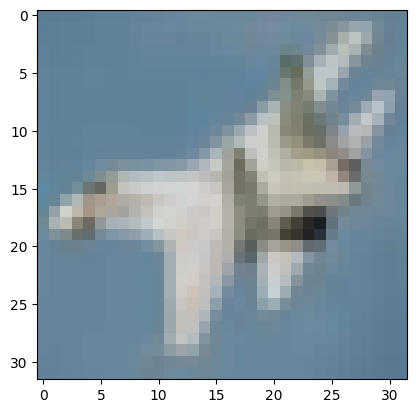

In [129]:
plt.imshow(x_test[10])

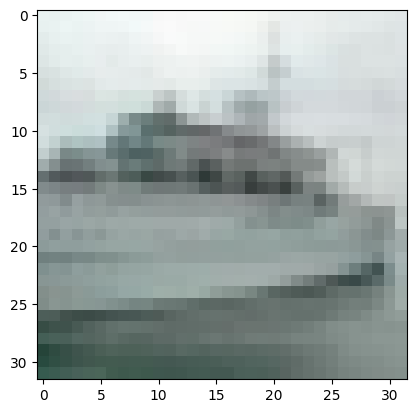

In [130]:
plt.imshow(x_test[80])

**Forma 2**

In [131]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models

tf.__version__

class_names = ['avión', 'coche', 'pájaro', 'gato', 'ciervo', 'perro', 'rana',
'caballo', 'barco', 'camión']

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train[:3000,:]
y_train = y_train[:3000]

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train.shape



inputs = tf.keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPool2D(2, 2)(x)
x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.Conv2D(64, 3, padding="same", activation="relu", name="last_conv")(x)
x = layers.MaxPool2D(2, 2)(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.summary()

model.compile(loss="sparse_categorical_crossentropy",
optimizer="Adam", metrics=["sparse_categorical_accuracy"])

model.fit(x_train, y_train, epochs=5)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy: {}".format(test_accuracy))

Model: "functional_273"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_46 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 2.0775 - sparse_categorical_accuracy: 0.2207
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7263 - sparse_categorical_accuracy: 0.3787
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5070 - sparse_categorical_accuracy: 0.4467
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3716 - sparse_categorical_accuracy: 0.5017
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2131 - sparse_categorical_accuracy: 0.5620
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4710 - sparse_categorical_accuracy: 0.4694
Test accuracy: 0.46939998865127563


**Ejercicio 2**

Crea la matriz de confusión y analiza los errores

In [132]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred_valor = model.predict(x_test)

y_pred = np.argmax(y_pred_valor, axis=1)

matriz_de_confusion = confusion_matrix(y_test, y_pred)
print(matriz_de_confusion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[[480  42  40   6  28   6  25  17 339  17]
 [ 52 666   5   1   6   4  26   6 159  75]
 [108  22 228  23 140 103 207  75  75  19]
 [ 69  32  67 104  84 227 244  95  44  34]
 [ 74  12  96  16 324  62 246 117  46   7]
 [ 40  15  78  55  78 433 141 104  44  12]
 [ 19  18  45  30  56  34 723  22  30  23]
 [ 58  13  32  20  79  81  94 559  37  27]
 [104  52  10   4   2  10  13  10 782  13]
 [ 53 244   9   5   5   9  32  25 223 395]]


**Ejercicio 3**


Mejora el entrenamiento de la red neuronal. Investiga el uso del
EarlyStopping con su argumento Pacience. Explica su uso.

- EarlyStopping: Es una técnica (conocida como callback en Keras) que detiene el proceso de entrenamiento de la red neuronal automáticamente cuando el modelo deja de mejorar. Su objetivo principal es ahorrar tiempo y, sobre todo, evitar el sobreentrenamiento (overfitting).

- Argumento patience: Define cuántas épocas consecutivas estamos dispuestos a "esperar" sin observar ninguna mejora antes de abortar el entrenamiento. Por ejemplo, si configuras patience=3 y tu modelo no logra reducir su margen de error durante 3 épocas seguidas, el entrenamiento se detendrá de inmediato.

In [133]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Configuramos el EarlyStopping
# monitor='val_loss': Le decimos que vigile el error de validación (test).
# patience=3: Si el error no baja durante 3 épocas seguidas, paramos.
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

# 2. Entrenamos el modelo pasándole el callback
# Al usar EarlyStopping, podemos poner un número alto de epochs (ej. 50),
# ya que la red se detendrá sola cuando deje de aprender.
model.fit(
    x_train,
    y_train,
    epochs=50,
    validation_data=(x_test, y_test), # Fundamental para que tenga algo que monitorear
    callbacks=[early_stopping]
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.0364 - sparse_categorical_accuracy: 0.6237 - val_loss: 1.4917 - val_sparse_categorical_accuracy: 0.4857
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.8943 - sparse_categorical_accuracy: 0.6887 - val_loss: 1.5041 - val_sparse_categorical_accuracy: 0.4983
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.7185 - sparse_categorical_accuracy: 0.7487 - val_loss: 1.6084 - val_sparse_categorical_accuracy: 0.5008
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4873 - sparse_categorical_accuracy: 0.8230 - val_loss: 2.0430 - val_sparse_categorical_accuracy: 0.4865


**Ejercicio 4**

Utiliza ModelCheckpoint combinado con EarlyStopping de tal forma que
recuperemos el mejor valor durante el entrenamiento. Investiga cómo se
usa y explica los argumentos que utiliza.

In [134]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configuración del EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

# Configuración del ModelCheckpoint
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo.keras',
    monitor='val_loss',
    save_best_only=True
)

# Entrenamiento aplicando los callbacks (aún sin el validation_split del ej. 5)
model.fit(
    x_train,
    y_train,
    epochs=50,
    validation_data=(x_test, y_test), # Usamos los datos de test temporalmente para validar
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.3288 - sparse_categorical_accuracy: 0.8887 - val_loss: 2.0983 - val_sparse_categorical_accuracy: 0.4973
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1895 - sparse_categorical_accuracy: 0.9437 - val_loss: 2.6428 - val_sparse_categorical_accuracy: 0.5041
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2375 - sparse_categorical_accuracy: 0.9257 - val_loss: 2.9349 - val_sparse_categorical_accuracy: 0.4969
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1103 - sparse_categorical_accuracy: 0.9667 - val_loss: 3.0474 - val_sparse_categorical_accuracy: 0.4942


**Ejercicio 5**

Usa un conjunto de validación (10% de las muestras de entrenamiento) al
entrenar el modelo. Para ello, explora el argumento validation_split del
método fit del modelo y explica su uso.

En el caso de tener las muestras separadas para validar, también se
podrían indicar directamente en vez de indicar que se coja un %:
`model.fit(… , validation_data=(x_val, y_val))`

In [135]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Mantenemos los callbacks configurados
early_stopping = EarlyStopping(monitor='val_loss', patience=3)
checkpoint = ModelCheckpoint(filepath='mejor_modelo.keras', monitor='val_loss', save_best_only=True)

# Entrenamiento usando validation_split en lugar de validation_data
model.fit(
    x_train,
    y_train,
    epochs=50,
    validation_split=0.10, # Separa el 10% para validación
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0678 - sparse_categorical_accuracy: 0.9778 - val_loss: 0.1097 - val_sparse_categorical_accuracy: 0.9700
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0540 - sparse_categorical_accuracy: 0.9852 - val_loss: 0.1074 - val_sparse_categorical_accuracy: 0.9533
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0727 - sparse_categorical_accuracy: 0.9785 - val_loss: 0.1207 - val_sparse_categorical_accuracy: 0.9600
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0769 - sparse_categorical_accuracy: 0.9733 - val_loss: 0.0772 - val_sparse_categorical_accuracy: 0.9733
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0334 - sparse_categorical_accuracy: 0.9907 - val_loss: 0.0861 - val_sparse_categorical_accuracy: 0.9633
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0174 - sparse_categorical_accuracy: 0.9952 - val_loss: 0.0871 - val_sparse_categorical_accuracy: 0.9700
Epoch 7/50
85/8

**Ejercicio 6**

Crea la gráfica para comprobar como va cambiando la precisión de las
muestras de entrenamiento y validación.
Para ello, es importante que guardes la salida del model.fit(…
`history = model.fit(…`
La guardamos en la variable history y así ya podemos mostrar la gráfica.

Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7405e-04 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0440 - val_sparse_categorical_accuracy: 0.9867
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3643e-04 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0442 - val_sparse_categorical_accuracy: 0.9867
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0592e-04 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0448 - val_sparse_categorical_accuracy: 0.9833


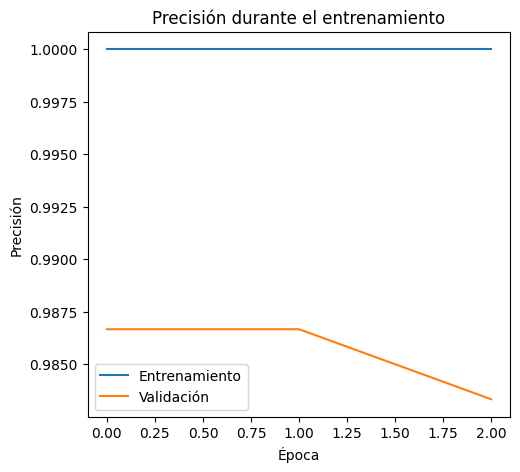

In [136]:
# 1. Entrenamos el modelo y guardamos el resultado en la variable 'history'
# (Se incluye el validation_split del Ejercicio 5)
history = model.fit(
    x_train,
    y_train,
    epochs=15, # Puedes ajustar las épocas según necesites
    validation_split=0.1,
    callbacks=[early_stopping, checkpoint]
)

# 2. Importamos la librería para dibujar (si no estaba importada ya)
import matplotlib.pyplot as plt

# 3. Creamos la gráfica
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)

# Añadimos las líneas de precisión de entrenamiento y validación
plt.plot(history.history['sparse_categorical_accuracy'], label='Entrenamiento')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validación')

# Añadimos título, etiquetas y leyenda
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Mostramos la gráfica
plt.show()

**Ejercicio 7**

Finalmente añade capas, tanto de convolución como en la totalmente
conectada (dense), modificando el número de neuronas y funciones de
activación a nuestro modelo inicial y haz un estudio viendo cual es la
mejor configuración para la clasificación de la base de datos Cifar 10.
También, comprueba como cambian las gráficas de la precisión con estas
nuevas configuraciones. Saca conclusiones.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - loss: 2.2226 - sparse_categorical_accuracy: 0.1511 - val_loss: 2.1178 - val_sparse_categorical_accuracy: 0.2633
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0665 - sparse_categorical_accuracy: 0.2296 - val_loss: 1.9371 - val_sparse_categorical_accuracy: 0.2933
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8731 - sparse_categorical_accuracy: 0.3015 - val_loss: 1.7520 - val_sparse_categorical_accuracy: 0.3467


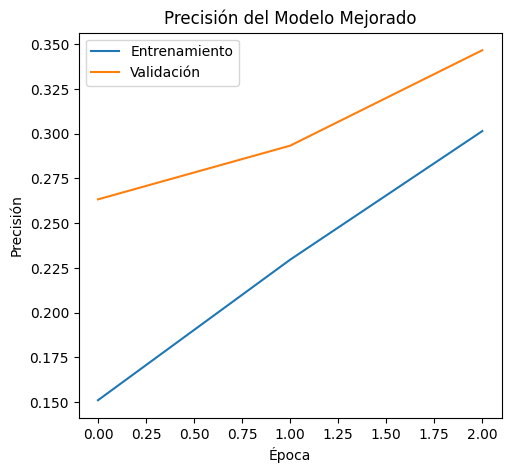

In [137]:
import tensorflow as tf

# 1. Definimos el NUEVO modelo secuencial mejorado
modelo_mejorado = tf.keras.models.Sequential()

# Bloque convolucional 1
modelo_mejorado.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding="same", activation="relu", input_shape=[32, 32, 3]))
modelo_mejorado.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding="same", activation="relu"))
modelo_mejorado.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding='valid'))
modelo_mejorado.add(tf.keras.layers.Dropout(0.25)) # Novedad: apagamos 25% de neuronas para no memorizar

# Bloque convolucional 2
modelo_mejorado.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"))
modelo_mejorado.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"))
modelo_mejorado.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding='valid'))
modelo_mejorado.add(tf.keras.layers.Dropout(0.25)) # Novedad

# Bloque convolucional 3 (Novedad respecto al inicial)
modelo_mejorado.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding="same", activation="relu"))
modelo_mejorado.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding='valid'))
modelo_mejorado.add(tf.keras.layers.Dropout(0.25))

# Clasificador final (Dense)
modelo_mejorado.add(tf.keras.layers.Flatten())
modelo_mejorado.add(tf.keras.layers.Dense(units=256, activation='relu')) # Aumentamos de 128 a 256
modelo_mejorado.add(tf.keras.layers.Dropout(0.5))
modelo_mejorado.add(tf.keras.layers.Dense(units=10, activation='softmax'))

# 2. Compilamos el modelo
modelo_mejorado.compile(loss="sparse_categorical_crossentropy", optimizer="Adam", metrics=["sparse_categorical_accuracy"])

# 3. Entrenamos guardando el historial
history_mejorado = modelo_mejorado.fit(x_train, y_train, epochs=20, validation_split=0.1, callbacks=[early_stopping, checkpoint])

# 4. Volvemos a dibujar la gráfica
plt.figure(figsize =(12,5))
plt.subplot(1, 2, 1)
plt.plot(history_mejorado.history['sparse_categorical_accuracy'], label='Entrenamiento')
plt.plot(history_mejorado.history['val_sparse_categorical_accuracy'], label='Validación')
plt.title('Precisión del Modelo Mejorado')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()

**Ejercicio 8**

Vuelve a crea la matriz de confusión y compárala con la del ejercicio 1

In [138]:
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Predicción con el modelo mejorado
y_pred_valor_mejorado = modelo_mejorado.predict(x_test)

# 2. Conversión a clases (obtener el índice de la probabilidad más alta)
y_pred_mejorado = np.argmax(y_pred_valor_mejorado, axis=1)

# 3. Calcular e imprimir la matriz de confusión en texto
matriz_de_confusion_mejorada = confusion_matrix(y_test, y_pred_mejorado)
print(matriz_de_confusion_mejorada)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[[681  57  56  36   1   7  24  39  51  48]
 [163 470  32  35   1  43  23  40  75 118]
 [146  30 278  82  14  48 309  83   4   6]
 [ 76  37 153 253   0 121 266  79   1  14]
 [ 91  16 164  78  44  32 482  87   1   5]
 [ 71  37 177 195  11 185 221  93   1   9]
 [ 25  30 114 124  14  18 609  59   0   7]
 [ 74  35 106 114  37  44 145 407   3  35]
 [574  79  38  39   0  27   7  25 159  52]
 [180 197  36  54   1  17  31  90  82 312]]


**Ejercicio 9**

Añade interpretabilidad al modelo. La técnica Grad-CAM permite explicar
visualmente las decisiones de las redes neuronales profundas ya que se
crea un mapa de calor que nos permite comprobar en dónde se fija una
red neuronal. Implementa Grad-CAM sobre la CNN de Cifar 10. Investiga
cómo funciona e implementa el modelo. Puedes utilizar cualquier tipo de
ayuda, pero debes explicarlo y entenderlo.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1621']]
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


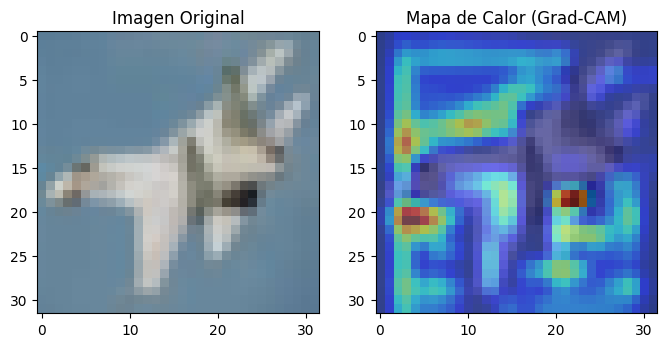

In [139]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2 # <--- IMPORTANTE: Importamos OpenCV para redimensionar

# 1. Seleccionamos una imagen de prueba (por ejemplo, la número 10)
img_array = np.expand_dims(x_test[10], axis=0)

# 2. Identificamos la última capa convolucional del modelo
ultima_capa_conv = model.get_layer("last_conv")

# 3. Creamos un modelo intermedio
modelo_gradcam = tf.keras.models.Model(
    [model.inputs],
    [ultima_capa_conv.output, model.output]
)

# 4. Calculamos los gradientes
with tf.GradientTape() as tape:
    salida_conv, predicciones = modelo_gradcam(img_array)
    clase_predicha = tf.argmax(predicciones[0])
    loss = predicciones[:, clase_predicha]

grads = tape.gradient(loss, salida_conv)

# 5. Procesamos el mapa de calor
pesos_promediados = tf.reduce_mean(grads, axis=(0, 1, 2))
salida_conv = salida_conv[0]
mapa_calor = salida_conv @ pesos_promediados[..., tf.newaxis]
mapa_calor = tf.squeeze(mapa_calor)

# Normalizamos
mapa_calor = tf.maximum(mapa_calor, 0) / tf.math.reduce_max(mapa_calor)
mapa_calor = mapa_calor.numpy()

# ---> LA SOLUCIÓN: Redimensionamos el mapa de 16x16 a 32x32 <---
mapa_calor_redimensionado = cv2.resize(mapa_calor, (32, 32))

# 6. Visualizamos
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(x_test[10])

plt.subplot(1, 2, 2)
plt.title("Mapa de Calor (Grad-CAM)")
plt.imshow(x_test[10])
# Usamos el mapa de calor que ya está redimensionado:
plt.imshow(mapa_calor_redimensionado, cmap='jet', alpha=0.5)

plt.show()